# Demo 5. reciprocalspaceship and Gemmi

**Companion to slide 14 of *Teaching Crystallographic Computing with Computational Notebooks*.**
27th Congress and General Assembly of the IUCr, Calgary, Alberta, 2026 August 17.

Blaine Mooers, PhD. Department of Biochemistry and Physiology, University of Oklahoma Health Campus.
blaine-mooers@ou.edu

## What this demonstration covers

1. DataFrames for reflection data with reciprocalspaceship.
2. Fast structure parsing with Gemmi.
3. Custom data transformations.
4. Integration with pandas and NumPy.

## Why this is the demonstration to show first

Every other notebook in this set needs a conda solve, a licensed binary, or a workstation.
This one installs in fifteen seconds on any machine and never fails in front of a class.
When you have twenty minutes and an unreliable network, show this one.

It is also the demonstration that reaches students who arrived from outside crystallography.
A student who already knows pandas knows most of reciprocalspaceship on the first slide,
because an `rs.DataSet` *is* a `pandas.DataFrame` that happens to carry a unit cell and a
space group. That is the whole design, and it is why people from machine learning can start
contributing to crystallography without first learning a bespoke file API.

In [1]:
import os

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

import pathlib
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
WORK = pathlib.Path("/content/rs_gemmi" if IN_COLAB else "./rs_gemmi").resolve()
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print("Working in", WORK)

Working in /Users/blaine/3285CCinJNiucr26/demos/rs_gemmi


In [ ]:
!pip -q install gemmi reciprocalspaceship matplotlib pandas numpy

In [2]:
import time
import urllib.request

import gemmi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reciprocalspaceship as rs

print("gemmi              :", gemmi.__version__)
print("reciprocalspaceship:", rs.__version__)
print("pandas             :", pd.__version__)
print("numpy              :", np.__version__)

gemmi              : 0.7.3
reciprocalspaceship: 1.0.7
pandas             : 2.3.3
numpy              : 2.5.2


## 1. Data

We use the deposited structure factors and coordinates for
[6YNQ](https://www.rcsb.org/structure/6YNQ), the SARS-CoV-2 main protease bound to
2-methyl-1-tetralone. Nothing here depends on the earlier notebooks, so this one stands
alone.

In [3]:
for name, url in [
    ("6YNQ.cif", "https://files.rcsb.org/download/6YNQ.cif"),
    ("6YNQ-sf.cif", "https://files.rcsb.org/download/6YNQ-sf.cif"),
]:
    if not (WORK / name).exists():
        urllib.request.urlretrieve(url, WORK / name)
    print(f"{name:14s} {(WORK / name).stat().st_size / 1e6:.2f} MB")

6YNQ.cif       0.66 MB
6YNQ-sf.cif    2.77 MB


In [4]:
# gemmi converts the deposited structure-factor CIF into MTZ in one command.
!gemmi cif2mtz 6YNQ-sf.cif 6YNQ.mtz

## 2. A reflection file as a data frame

In [5]:
ds = rs.read_mtz("6YNQ.mtz")

print("Type          :", type(ds).__mro__[:3])
print("Is a DataFrame:", isinstance(ds, pd.DataFrame))
print("Cell          :", ds.cell)
print("Space group   :", ds.spacegroup.hm, " number", ds.spacegroup.number)
print("Shape         :", ds.shape)
print("Index         :", ds.index.names)
ds.head()

Type          : (<class 'reciprocalspaceship.dataset.DataSet'>, <class 'pandas.core.frame.DataFrame'>, <class 'pandas.core.generic.NDFrame'>)
Is a DataFrame: True
Cell          : <gemmi.UnitCell(113.083, 53.154, 44.65, 90, 102.963, 90)>
Space group   : C 1 2 1  number 5
Shape         : (26126, 7)
Index         : ['H', 'K', 'L']


FreeR_flag      FP   SIGFP  FWT  PHWT  DELFWT  PHDELWT
H   K L                                                        
-64 0 3           1  0.9504  0.6965  NaN   NaN     NaN      NaN
      4           1  0.8486  0.6288  NaN   NaN     NaN      NaN
      5           1  0.7023  0.5246  NaN   NaN     NaN      NaN
      6           1    1.06  0.7667  NaN   NaN     NaN      NaN
      7           1   1.295  0.8997  NaN   NaN     NaN      NaN

The two things a plain `DataFrame` lacks are attached as attributes, not buried in a
reader object. That single decision is what makes the rest of the library feel like pandas.

In [6]:
# Columns carry MTZ types, so a round trip through disk does not lose meaning.
pd.DataFrame(
    {"dtype": ds.dtypes.astype(str), "mtz_code": [ds[c].dtype.mtztype for c in ds.columns]}
)

,dtype,mtz_code
FreeR_flag,MTZInt,I
FP,SFAmplitude,F
SIGFP,Stddev,Q
FWT,SFAmplitude,F
PHWT,Phase,P
DELFWT,SFAmplitude,F
PHDELWT,Phase,P


## 3. The crystallographic methods

These are the operations that a pandas user cannot write themselves without knowing
crystallography, and they are exactly the ones reciprocalspaceship supplies.

In [7]:
ds = ds.compute_dHKL()
ds = ds.label_centrics()
ds = ds.compute_multiplicity()  # the epsilon factor

print("Resolution   : {:.2f} to {:.2f} angstroms".format(ds["dHKL"].max(), ds["dHKL"].min()))
print("Centric      : {} of {} reflections ({:.1f} percent)".format(
    int(ds["CENTRIC"].sum()), len(ds), 100 * ds["CENTRIC"].mean()))
print("Epsilon > 1  : {} reflections".format(int((ds["EPSILON"] > 1).sum())))
ds.head()

Resolution   : 55.10 to 1.75 angstroms
Centric      : 1264 of 26126 reflections (4.8 percent)
Epsilon > 1  : 26126 reflections


FreeR_flag      FP   SIGFP  FWT  PHWT  DELFWT  PHDELWT      dHKL  \
H   K L                                                                     
-64 0 3           1  0.9504  0.6965  NaN   NaN     NaN      NaN  1.756638   
      4           1  0.8486  0.6288  NaN   NaN     NaN      NaN   1.76288   
      5           1  0.7023  0.5246  NaN   NaN     NaN      NaN  1.766271   
      6           1    1.06  0.7667  NaN   NaN     NaN      NaN  1.766762   
      7           1   1.295  0.8997  NaN   NaN     NaN      NaN  1.764345   

         CENTRIC  EPSILON  
H   K L                    
-64 0 3     True        2  
      4     True        2  
      5     True        2  
      6     True        2  
      7     True        2

In [8]:
# Symmetry, straight from the space group object gemmi hands over.
sg = ds.spacegroup
print(f"{sg.hm}, number {sg.number}, {len(sg.operations())} operations in the unit cell\n")
for op in sg.operations():
    print("   ", op.triplet())

C 1 2 1, number 5, 4 operations in the unit cell

    x,y,z
    -x,y,-z
    x+1/2,y+1/2,z
    -x+1/2,y+1/2,-z


In [9]:
# Reducing to the asymmetric unit and expanding back out.
asu = ds.hkl_to_asu()
print("Reflections in the file        :", len(ds))
print("After mapping to the ASU       :", len(asu))
print("Unique Miller indices in ASU   :", asu.index.nunique())

# expand_to_p1 only applies to merged data, so ask before calling it.
if getattr(ds, "merged", False):
    expanded = ds.expand_to_p1()
    print("Expanded to P1                 :", len(expanded))
else:
    print("This file is unmerged, so expand_to_p1 does not apply.")

Reflections in the file        : 26126
After mapping to the ASU       : 26126
Unique Miller indices in ASU   : 26126
Expanded to P1                 : 50974


## 4. Custom transformations, which is the point

Anything a student can express in pandas now works on reflection data. Three examples that
each take one screen.

### A Wilson plot

The mean intensity, corrected for the atomic form factor falloff, decays as
$\exp(-2B\sin^2\theta/\lambda^2)$. Fitting the slope of the log gives an overall B factor
and tells a student immediately whether their crystal was well ordered.

Using column FP


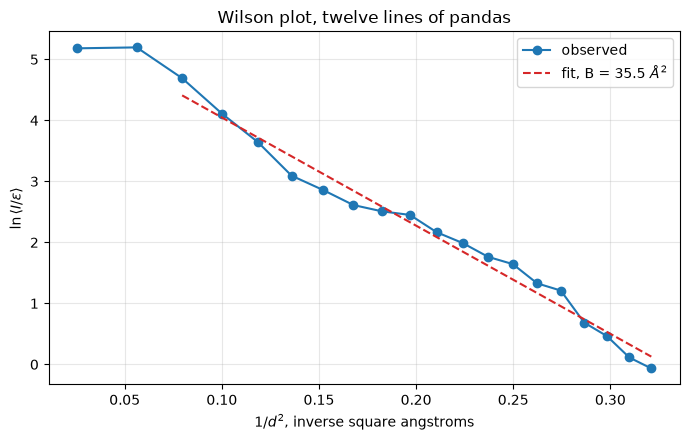

In [10]:
icol = next(c for c in ["I", "IMEAN", "I-obs", "F_meas_au", "FP"] if c in ds.columns)
print("Using column", icol)

wilson = ds[[icol, "dHKL", "EPSILON", "CENTRIC"]].dropna().copy()
wilson["invd2"] = 1.0 / wilson["dHKL"] ** 2
if ds[icol].dtype.mtztype in ("F", "G"):
    wilson["Ival"] = wilson[icol].to_numpy(float) ** 2
else:
    wilson["Ival"] = wilson[icol].to_numpy(float)
wilson["Inorm"] = wilson["Ival"] / wilson["EPSILON"].to_numpy(float)

# Twenty equal-population shells.
edges = np.quantile(wilson["invd2"], np.linspace(0, 1, 21))
wilson["shell"] = np.clip(np.digitize(wilson["invd2"], edges[1:-1]), 0, 19)

shells = wilson.groupby("shell").agg(
    invd2=("invd2", "mean"), d=("dHKL", "mean"), Imean=("Inorm", "mean"), n=("Inorm", "size")
)
shells["lnI"] = np.log(shells["Imean"])

# Fit the high-resolution half, where the Wilson approximation actually holds.
high = shells[shells["d"] < 4.0]
slope, intercept = np.polyfit(high["invd2"], high["lnI"], 1)
B_wilson = -2.0 * slope

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(shells["invd2"], shells["lnI"], marker="o", label="observed")
ax.plot(high["invd2"], slope * high["invd2"] + intercept, "--", c="tab:red",
        label=f"fit, B = {B_wilson:.1f} $\\AA^2$")
ax.set_xlabel(r"$1/d^2$, inverse square angstroms")
ax.set_ylabel(r"$\ln \langle I/\epsilon \rangle$")
ax.set_title("Wilson plot, twelve lines of pandas")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Centric and acentric intensity distributions

The ratio $\langle I^2 \rangle / \langle I \rangle^2$ is 2 for acentric reflections and 3
for centric ones. A value near 1.5 in a shell where it should be 2 is the classic
fingerprint of merohedral twinning. Two lines of `groupby` and the class has done a
twinning test.

,n,mean,second_moment,expected
CENTRIC,,,,
False,24289,0.987,2.769,2.0
True,1239,1.265,7.132,3.0


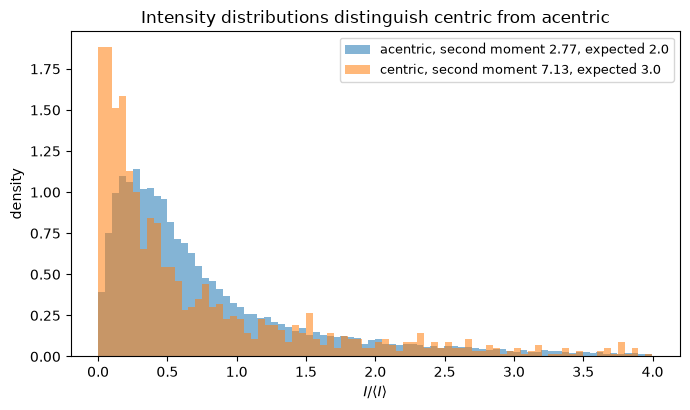

In [11]:
norm = wilson.copy()
norm["Enorm"] = norm.groupby("shell")["Inorm"].transform(lambda x: x / x.mean())

moments = norm.groupby("CENTRIC")["Enorm"].agg(
    n="size", mean="mean", second_moment=lambda x: (x**2).mean()
)
# Map the theoretical value onto whichever groups are present, because a file that has
# been reduced to the asymmetric unit of a low-symmetry group may hold no centrics.
moments["expected"] = [3.0 if centric else 2.0 for centric in moments.index]
display(moments.round(3))

fig, ax = plt.subplots(figsize=(7, 4.2))
for centric, label, expected in [(False, "acentric", 2.0), (True, "centric", 3.0)]:
    subset = norm.loc[norm["CENTRIC"] == centric, "Enorm"]
    if subset.empty:
        print(f"No {label} reflections in this file.")
        continue
    ax.hist(subset[subset < 4], bins=80, density=True, alpha=0.55,
            label=f"{label}, second moment {(subset**2).mean():.2f}, expected {expected}")
ax.set_xlabel(r"$I / \langle I \rangle$")
ax.set_ylabel("density")
ax.set_title("Intensity distributions distinguish centric from acentric")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Resolution-shell statistics as a one-liner

The table that every processing program prints at the end is a `groupby`.

In [12]:
stats = wilson.groupby("shell").agg(
    d_high=("dHKL", "min"), d_low=("dHKL", "max"), n=("Ival", "size"), I_mean=("Ival", "mean")
)
stats["d_range"] = stats.apply(lambda r: f"{r['d_low']:.2f} - {r['d_high']:.2f}", axis=1)
display(stats[["d_range", "n", "I_mean"]].round(1))

,d_range,n,I_mean
shell,,,
0,27.55 - 4.83,1277,355.6
1,4.83 - 3.82,1276,361.1
2,3.82 - 3.33,1277,217.8
3,3.33 - 3.02,1276,122.1
4,3.02 - 2.80,1276,76.3
5,2.80 - 2.63,1277,44.1
6,2.63 - 2.50,1276,34.8
7,2.50 - 2.39,1276,27.3
8,2.39 - 2.30,1277,24.6


## 5. Gemmi, and why speed matters for teaching

Gemmi is a C++ library with a thin Python skin. Parsing a large mmCIF file takes a fraction
of a second, which means a demonstration can reparse a structure inside a loop without
anybody watching a progress bar. Slow tools push instructors toward pre-computed results,
and pre-computed results are exactly what makes a demonstration feel like a magic trick.

In [13]:
t0 = time.perf_counter()
st = gemmi.read_structure("6YNQ.cif")
t_parse = time.perf_counter() - t0

st.setup_entities()
print(f"Parsed {(WORK / '6YNQ.cif').stat().st_size / 1e6:.2f} MB in {1000 * t_parse:.0f} ms")
print("Name        :", st.name)
print("Resolution  :", st.resolution, "angstroms")
print("Space group :", st.spacegroup_hm)
print("Cell        :", st.cell)
print("Models      :", len(st))
print("Chains      :", [c.name for c in st[0]])
print("Atom sites  :", st[0].count_atom_sites())

Parsed 0.66 MB in 11 ms
Name        : 6YNQ
Resolution  : 1.8 angstroms
Space group : C 1 2 1
Cell        : <gemmi.UnitCell(113.083, 53.154, 44.65, 90, 102.963, 90)>
Models      : 1
Chains      : ['A']
Atom sites  : 5345


In [14]:
# The model as a data frame, so the same pandas skills apply to coordinates.
atoms = pd.DataFrame(
    [
        dict(chain=ch.name, seqid=res.seqid.num, resname=res.name, atom=at.name,
             element=at.element.name, x=at.pos.x, y=at.pos.y, z=at.pos.z,
             occ=at.occ, b=at.b_iso)
        for ch in st[0]
        for res in ch
        for at in res
    ]
)
print(atoms.shape)
atoms.head()

(5345, 10)


,chain,seqid,resname,atom,element,x,y,z,occ,b
0,A,1,SER,N,N,-2.54356,4.68250,-16.77435,1.0,33.023701
1,A,1,SER,CA,C,-1.99551,5.90673,-16.13316,1.0,34.614780
2,A,1,SER,C,C,-2.40930,5.96871,-14.66545,1.0,30.625879
3,A,1,SER,O,O,-3.01974,5.03679,-14.14475,1.0,27.052589
4,A,1,SER,CB,C,-2.46060,7.16318,-16.86996,1.0,38.471039


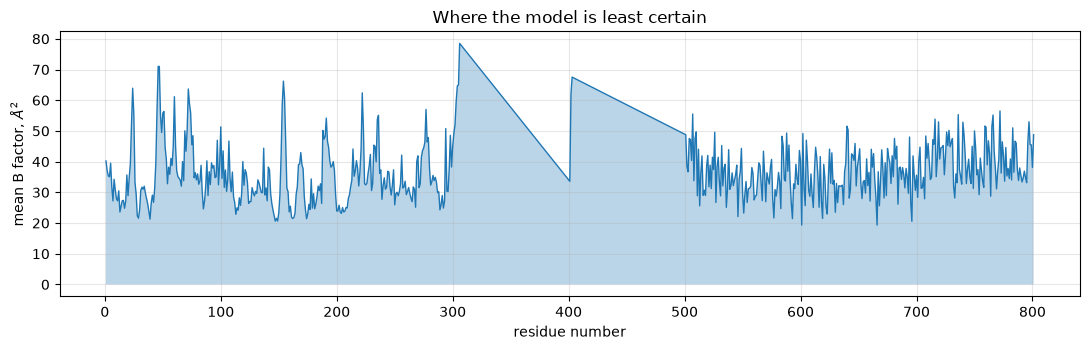

,seqid,resname,b_mean,n_atoms
305,306,GLN,78.514125,17
45,46,SER,71.021208,11
46,47,GLU,71.006418,15
308,403,CL,67.528992,1
153,154,TYR,66.225780,21
304,305,PHE,65.006033,20
303,304,THR,64.662797,14
23,24,THR,63.916167,14


In [15]:
# Which residues are the most mobile? A groupby answers it.
by_residue = (
    atoms[atoms["chain"] == atoms["chain"].iloc[0]]
    .groupby(["seqid", "resname"], as_index=False)
    .agg(b_mean=("b", "mean"), n_atoms=("b", "size"))
)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(by_residue["seqid"], by_residue["b_mean"], lw=1)
ax.fill_between(by_residue["seqid"], by_residue["b_mean"], alpha=0.3)
ax.set_xlabel("residue number")
ax.set_ylabel(r"mean B factor, $\AA^2$")
ax.set_title("Where the model is least certain")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

top = by_residue.nlargest(8, "b_mean")
display(top)

In [16]:
# Neighbour search. Finding what contacts the ligand takes three lines.
ns = gemmi.NeighborSearch(st, 5.0).populate()

def is_ligand(res):
    """True for anything that is neither a standard residue nor a water."""
    info = gemmi.find_tabulated_residue(res.name)
    if info is None:
        return True
    return not (info.is_amino_acid() or info.is_nucleic_acid() or info.is_water())


ligand_atoms = [
    (ch.name, res, at) for ch in st[0] for res in ch for at in res if is_ligand(res)
]
print(f"{len(ligand_atoms)} non-protein, non-water atoms")

if ligand_atoms:
    contacts = []
    for chname, res, at in ligand_atoms:
        for mark in ns.find_atoms(at.pos, "\0", radius=4.0):
            cra = mark.to_cra(st[0])
            if cra.residue.name == res.name:
                continue
            contacts.append(
                dict(
                    ligand=f"{res.name}{res.seqid.num}",
                    ligand_atom=at.name,
                    partner=f"{cra.chain.name}/{cra.residue.name}{cra.residue.seqid.num}",
                    partner_atom=cra.atom.name,
                    distance=round(at.pos.dist(cra.atom.pos), 2),
                )
            )
    contact_df = pd.DataFrame(contacts).sort_values("distance")
    display(contact_df.head(15))

34 non-protein, non-water atoms


,ligand,ligand_atom,partner,partner_atom,distance
33,P6N401,C01,A/CYS145,SG,1.61
115,P6N401,O12,A/HIS163,HE2,1.81
144,P6N401,H013,A/CYS145,SG,1.91
32,P6N401,C01,A/CYS145,SG,1.93
160,P6N401,H012,A/CYS145,SG,1.93
143,P6N401,H013,A/CYS145,SG,2.09
291,DMS402,O,A/ARG76,HG3,2.38
138,P6N401,H013,A/CYS145,H,2.41
137,P6N401,H013,A/CYS145,H,2.42
185,P6N401,H021,A/CYS145,SG,2.48


In [17]:
# Unit cell arithmetic and symmetry, without leaving Python.
cell = st.cell
print("Volume          : {:.0f} cubic angstroms".format(cell.volume))
print("Fractionalize   :", cell.fractionalize(gemmi.Position(10, 20, 30)))
print("d spacing (1,0,0):", round(cell.calculate_d((1, 0, 0)), 2), "angstroms")
print("d spacing (0,0,2):", round(cell.calculate_d((0, 0, 2)), 2), "angstroms")

sg = gemmi.find_spacegroup_by_name(st.spacegroup_hm)
print("\nSpace group     :", sg.hm, "  point group", sg.point_group_hm())
print("Crystal system  :", sg.crystal_system_str())
print("Centring        :", sg.centring_type())

Volume          : 261543 cubic angstroms
Fractionalize   : <gemmi.Fractional(0.149498, 0.376265, 0.689463)>
d spacing (1,0,0): 110.2 angstroms
d spacing (0,0,2): 21.76 angstroms

Space group     : C 1 2 1   point group 2
Crystal system  : monoclinic
Centring        : C


## 6. Putting the two together

Compute structure factors from the model with gemmi, join them onto the observed data with
pandas, and the correlation plot every crystallographer looks at falls out.

In [18]:
D_MIN = 2.5

st_calc = gemmi.read_structure("6YNQ.cif")
st_calc.setup_entities()
st_calc.remove_hydrogens()

dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN
dc.rate = 1.5
dc.set_grid_cell_and_spacegroup(st_calc)
dc.put_model_density_on_grid(st_calc[0])
asu_data = gemmi.transform_map_to_f_phi(dc.grid, half_l=True).prepare_asu_data(dmin=D_MIN)

idx = np.array(asu_data.miller_array)
calc = rs.DataSet(
    {
        "H": idx[:, 0],
        "K": idx[:, 1],
        "L": idx[:, 2],
        "FCALC": np.abs(asu_data.value_array),
        "PHICALC": np.degrees(np.angle(asu_data.value_array)),
    }
)

# Give the Miller columns the MTZ HKL dtype before they become the index. Without this
# the DataSet will not write to MTZ and will not join onto a DataSet read from a file.
for label in ("H", "K", "L"):
    calc[label] = calc[label].astype("HKL")
calc["FCALC"] = calc["FCALC"].astype("SFAmplitude")
calc["PHICALC"] = calc["PHICALC"].astype("Phase")
calc = calc.set_index(["H", "K", "L"])
calc.cell = ds.cell
calc.spacegroup = ds.spacegroup
calc.merged = True

print(f"{len(calc)} calculated structure factors to {D_MIN} angstroms")
calc.head()

9074 calculated structure factors to 2.5 angstroms


FCALC     PHICALC
H   K L                        
-45 1 3  172.280823 -171.522522
      4  301.577118   86.009933
      5  215.798538 -175.569107
-44 0 1  135.650726 -179.999954
      2  335.360229 -179.999985

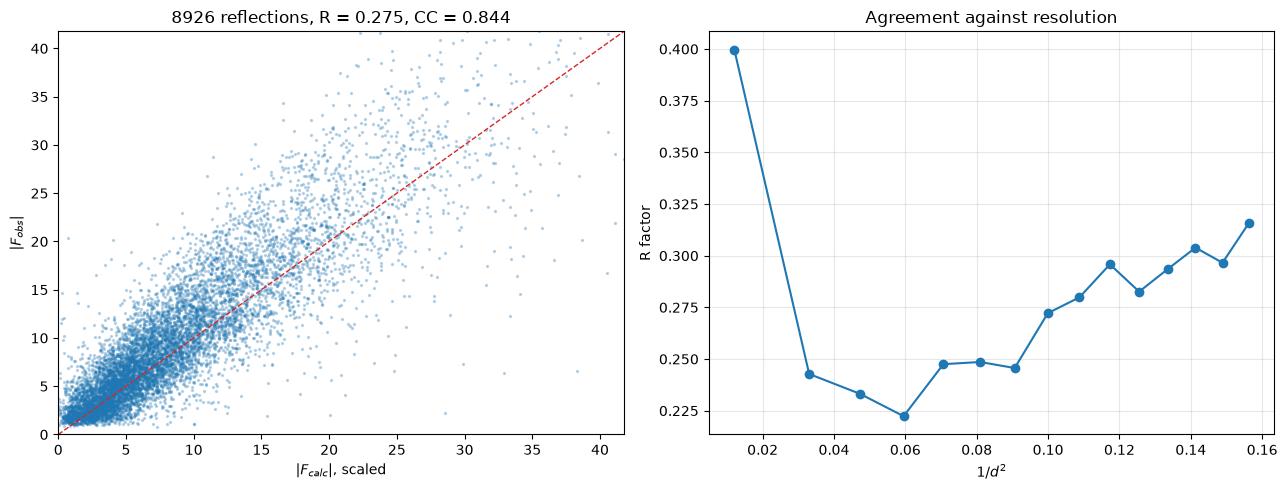

In [19]:
fcol = next((c for c in ["FP", "F-obs-filtered", "F_meas_au", "F"] if c in ds.columns), None)
if fcol is None:
    ds["FOBS"] = np.sqrt(np.clip(ds[icol].to_numpy(float), 0, None))
    fcol = "FOBS"

joined = ds[[fcol, "dHKL"]].join(calc, how="inner").dropna()
fo = joined[fcol].to_numpy(float)
fc = joined["FCALC"].to_numpy(float)
scale = (fo * fc).sum() / (fc * fc).sum()
fc = scale * fc

r = np.abs(fo - fc).sum() / fo.sum()
cc = np.corrcoef(fo, fc)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(fc, fo, s=2, alpha=0.25)
lim = [0, np.percentile(fo, 99.5)]
axes[0].plot(lim, lim, "--", c="tab:red", lw=1)
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel(r"$|F_{calc}|$, scaled")
axes[0].set_ylabel(r"$|F_{obs}|$")
axes[0].set_title(f"{len(joined)} reflections, R = {r:.3f}, CC = {cc:.3f}")

joined = joined.assign(FCALC_SCALED=fc, FOBS_=fo)
edges = np.quantile(1 / joined["dHKL"] ** 2, np.linspace(0, 1, 16))
joined["shell"] = np.clip(np.digitize(1 / joined["dHKL"] ** 2, edges[1:-1]), 0, 14)
per_shell = joined.groupby("shell").apply(
    lambda g: pd.Series(
        {
            "d": g["dHKL"].mean(),
            "R": np.abs(g["FOBS_"] - g["FCALC_SCALED"]).sum() / g["FOBS_"].sum(),
        }
    ),
    include_groups=False,
)
axes[1].plot(1 / per_shell["d"] ** 2, per_shell["R"], marker="o")
axes[1].set_xlabel(r"$1/d^2$")
axes[1].set_ylabel("R factor")
axes[1].set_title("Agreement against resolution")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Writing back out

A `DataSet` writes an MTZ that any crystallographic program will read. The loop is closed,
and anything a student invents in pandas can re-enter the standard pipeline.

In [20]:
out = joined[[fcol, "FCALC_SCALED"]].copy()
out.rename(columns={fcol: "FOBS", "FCALC_SCALED": "FCALC"}, inplace=True)
out["FOBS"] = out["FOBS"].astype("SFAmplitude")
out["FCALC"] = out["FCALC"].astype("SFAmplitude")
out.cell = ds.cell
out.spacegroup = ds.spacegroup
out.write_mtz("fo_fc.mtz")

check = gemmi.read_mtz_file("fo_fc.mtz")
print("Wrote fo_fc.mtz")
print("  space group :", check.spacegroup.hm)
print("  cell        :", check.cell)
print("  columns     :", [c.label for c in check.columns])
print("  reflections :", check.nreflections)

Wrote fo_fc.mtz
  space group : C 1 2 1
  cell        : <gemmi.UnitCell(113.083, 53.154, 44.65, 90, 102.963, 90)>
  columns     : ['H', 'K', 'L', 'FOBS', 'FCALC']
  reflections : 8926


In [21]:
# Format conversion, which is most of what a working crystallographer does with gemmi.
st.write_pdb("6YNQ.pdb")
st.write_minimal_pdb("6YNQ_minimal.pdb")
print("mmCIF in, PDB out. Sizes in MB:")
for name in ["6YNQ.cif", "6YNQ.pdb", "6YNQ_minimal.pdb", "6YNQ.mtz", "fo_fc.mtz"]:
    print(f"   {name:20s} {(WORK / name).stat().st_size / 1e6:.2f}")

mmCIF in, PDB out. Sizes in MB:
   6YNQ.cif             0.66
   6YNQ.pdb             0.44
   6YNQ_minimal.pdb     0.43
   6YNQ.mtz             1.05
   fo_fc.mtz            0.18


## Exercises

1. Compute the Wilson B factor for each of the three demonstration datasets you have on
   hand and rank the crystals by order.
2. Write a function that takes an `rs.DataSet` and returns the fraction of reflections above
   an I over sigma cutoff, shell by shell. Use it to pick a resolution limit, then argue
   with a classmate about the cutoff.
3. Use `ds.stack_anomalous()` to build a table of anomalous differences and plot their
   magnitude against resolution. What element could account for the signal?
4. Load two different structures with gemmi, superpose them with
   `gemmi.calculate_superposition`, and plot the per-residue displacement.
5. Time `gemmi.read_structure` against a pure-Python PDB parser you write yourself. Report
   the ratio, then explain to the class why the ratio matters for teaching.

## Sources

* reciprocalspaceship. Greisman, J. B., Dalton, K. M. and Hekstra, D. R. (2021).
  *J. Appl. Cryst.* **54**, 1521-1529. https://doi.org/10.1107/S160057672100755X
* Gemmi. Wojdyr, M. (2022). *J. Open Source Software* **7**, 4200. https://doi.org/10.21105/joss.04200
* PDB entry 6YNQ. https://www.rcsb.org/structure/6YNQ